# Experiment 2: Long-Form Truthfulness Evaluation on FactScore-Bio

**Authors:** Renu Chikkam · Alissa Josy — University of South Florida

**Goal:** Evaluate how well truth methods can score individual factual claims inside long-form LLM-generated biographies.

**Pipeline:**
1. LLaMA-3-8B generates a biography for each FactScore-Bio question
2. GPT-4o-mini decomposes each biography into atomic claims
3. Truth methods score each claim via `NaiveApplication`
4. SAFE algorithm (Google Search + GPT-4o-mini) labels each claim as correct/incorrect
5. AUROC and PRR are computed at the dataset level across all claims

**Model:** LLaMA-3-8B only (GPT-4o-mini is used as a helper for decomposition + SAFE, NOT for generation)

**Truth Methods:** LARS, Semantic Entropy, SAR, MiniCheck, SelfDetection, Verbalized Confidence

## 0. Install Dependencies

In [3]:
!pip install -q transformers==4.40.0
!pip install -q TruthTorchLM
!pip install -q litellm accelerate
!pip install -q google-search-results
!pip install -q datasets
!pip install -q "minicheck[llm]@git+https://github.com/Liyan06/MiniCheck.git@main"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.20.0 requires tokenizers>=0.21.1, but you have tokenizers 0.19.1 which is incompatible.
vllm 0.20.0 requires transformers!=5.0.*,!=5.1.*,!=5.2.*,!=5.3.*,!=5.4.*,!=5.5.0,>=4.56.0, but you have transformers 4.40.0 which is incompatible.
compressed-tensors 0.15.0.1 requires transformers>=4.45.0, but you have transformers 4.40.0 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports

In [6]:
import os
import json
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import TruthTorchLM as ttlm
import TruthTorchLM.long_form_generation as LFG

print("TruthTorchLM imported successfully.")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

TruthTorchLM imported successfully.
CUDA available: True
GPU: Tesla T4


## 2. API Keys

We use Kaggle Secrets to avoid exposing API keys in the notebook.


In [7]:
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()

os.environ["OPENAI_API_KEY"]          = secrets.get_secret("OPENAI_API_KEY")
os.environ["SERPER_API_KEY"]          = secrets.get_secret("SERPER_API_KEY")
os.environ["HUGGING_FACE_HUB_TOKEN"]  = secrets.get_secret("HF_TOKEN")

print("API keys loaded successfully.")

API keys loaded successfully.


## 3. Load LLaMA-3-8B

LLaMA-3-8B is the **only model used for biography generation**. GPT-4o-mini is only used as a helper tool for decomposition and SAFE — never for generation.

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=os.environ["HUGGING_FACE_HUB_TOKEN"]
)

print("Loading model (this takes a few minutes)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,  
    device_map="auto",          
    token=os.environ["HUGGING_FACE_HUB_TOKEN"]
)
model.eval()
print("Model loaded successfully!")

Loading tokenizer...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model loaded successfully!


## 4. Define Truth Methods

These are the truth methods used in this experiment, chosen to cover different access levels and supervision types. Note: MiniCheck was excluded due to dependency conflicts, and GoogleSearchCheck required an additional API key. We therefore evaluate 5 representative methods plus TokenSAR.

| Method | Access | Supervision | Sampling? |
|---|---|---|---|
| LARS | Grey-box | Supervised | No |
| SAR | Grey-box | Self-supervised | Yes |
| PTrue | Grey-box | Self-supervised | No |
| Confidence | Grey-box | Self-supervised | No |
| VerbalizedConfidence | Black-box | Self-supervised | No |
| TokenSAR | Grey-box | Self-supervised | No |

In [9]:
from sentence_transformers import CrossEncoder
cpu_cross_encoder = CrossEncoder("cross-encoder/stsb-roberta-large", num_labels=1, device="cpu")

lars = ttlm.truth_methods.LARS(device="cpu")
sar = ttlm.truth_methods.SAR(number_of_generations=2, model_for_similarity=cpu_cross_encoder, similarity_model_device="cpu")
p_true = ttlm.truth_methods.PTrue()
confidence = ttlm.truth_methods.Confidence()
verbalized_confidence = ttlm.truth_methods.VerbalizedConfidence()
token_sar = ttlm.truth_methods.TokenSAR()

truth_methods = [lars, sar, p_true, confidence, verbalized_confidence, token_sar]
METHOD_NAMES = ["LARS", "SAR", "PTrue", "Confidence", "VerbalizedConfidence", "TokenSAR"]

print(f"Defined {len(truth_methods)} truth methods: {METHOD_NAMES}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/219 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Defined 6 truth methods: ['LARS', 'SAR', 'PTrue', 'Confidence', 'VerbalizedConfidence', 'TokenSAR']


## 5. Set Up the Long-Form Pipeline

Three components work together:
1. **StructuredDecompositionAPI** — GPT-4o-mini splits each biography into atomic claims
2. **NaiveApplication** — adapts all 6 truth methods to score at the claim level
3. **ClaimEvaluator** — SAFE algorithm uses Google Search to label each claim as correct/incorrect

In [11]:
# GPT-4o-mini splits biography text into individual atomic facts
decomp_method = LFG.StructuredDecompositionAPI(
    model="gpt-4o-mini",
    decomposition_depth=1  # sentence-level decomposition
)

# Wraps all 6 truth methods so they can score individual claims
# instead of full biography outputs
naive_claim_checker = LFG.NaiveApplication(
    truth_methods=truth_methods
)

# SAFE: does Google Search + GPT-4o-mini judgment for each claim
# to determine if it is actually correct or not
safe_evaluator = LFG.ClaimEvaluator(
    rater="gpt-4o-mini",
    tokenizer=None,
    max_steps=3,     # up to 3 rounds of Google search per claim
    max_retries=5,  # retry if GPT response is unparseable
    num_searches=2   # fetch 2 search results per query
)

print("Pipeline ready:")
print("  Decomposition : StructuredDecompositionAPI (gpt-4o-mini)")
print("  Claim checker : NaiveApplication with", len(truth_methods), "truth methods")
print("  Claim labeler : SAFE (gpt-4o-mini + Google Search via Serper)")

Pipeline ready:
  Decomposition : StructuredDecompositionAPI (gpt-4o-mini)
  Claim checker : NaiveApplication with 6 truth methods
  Claim labeler : SAFE (gpt-4o-mini + Google Search via Serper)


## 6. Load FactScore-Bio Dataset

FactScore-Bio contains biography questions like "Tell me a bio of [person]."
We use 20 questions.
After decomposition each biography yields ~20-35 atomic claims, giving us 1,000+ claims total.

In [12]:
from datasets import load_dataset

NUM_QUESTIONS = 20
SEED = 42

raw_dataset = load_dataset("dskar/FActScore", split="test")

random.seed(SEED)
all_questions = [{"question": f"Tell me a bio of {row['entity']}.", "context": ""} for row in raw_dataset]
factscore_bio = random.sample(all_questions, min(NUM_QUESTIONS, len(all_questions)))

print(f"Loaded {len(factscore_bio)} FactScore-Bio questions.")
print("\nSample questions:")
for q in factscore_bio[:3]:
    print(" -", q["question"])

README.md: 0.00B [00:00, ?B/s]

factscore_eval_20250729_222645.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Loaded 20 FactScore-Bio questions.

Sample questions:
 - Tell me a bio of Marcel Hernández.
 - Tell me a bio of Kajal Aggarwal.
 - Tell me a bio of Braulio Lara.


In [13]:
# Patch for SAFE SerperAPI parse bug
import TruthTorchLM.long_form_generation.utils.safe_utils as safe_utils

def patched_parse_results(self, results):
    snippets = self._parse_snippets(results)
    # flatten any nested lists
    flat = []
    for s in snippets:
        if isinstance(s, list):
            flat.extend([str(x) for x in s])
        else:
            flat.append(str(s))
    return " ".join(flat)

safe_utils.SerperAPI._parse_results = patched_parse_results
print("Patch applied successfully!")

Patch applied successfully!


## 7. Run Experiment 2

This cell runs the full pipeline for all 20 questions:
- LLaMA-3-8B generates each biography (GPU)
- GPT-4o-mini decomposes it into claims (API)
- All 6 truth methods score each claim (GPU)
- SAFE verifies each claim via Google Search (API)


In [14]:
results = LFG.evaluate_truth_method_long_form(
    dataset=factscore_bio,
    model=model,
    tokenizer=tokenizer,
    decomp_method=decomp_method,
    claim_check_methods=[naive_claim_checker],
    claim_evaluator=safe_evaluator,
    sample_level_eval_metrics=["f1"],
    dataset_level_eval_metrics=["auroc", "prr"],
    size_of_data=NUM_QUESTIONS,
    seed=SEED,
    max_new_tokens=512,  
    do_sample=False,     
    temperature=1.0,
)

print("\nExperiment 2 complete!")

  0%|          | 0/20 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Decomposing the generated text...


[transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Applying claim check method  NaiveApplication


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=1024) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=1024) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max

...

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=1024) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=1024) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max

Checking for claim support by google search...


100%|██████████| 20/20 [1:35:06<00:00, 285.34s/it]

Time ellapsed for google search: 43.820655822753906



Experiment 2 complete!


## 8. Save Raw Results

Run this immediately after Cell 7 finishes.

In [15]:
def convert_numpy(obj):
    """Convert numpy types to native Python for JSON serialization."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

with open("experiment2_raw_results.json", "w") as f:
    json.dump(convert_numpy(results), f, indent=2)

print("Results saved to experiment2_raw_results.json")

Results saved to experiment2_raw_results.json


## 9. Results Table — AUROC and PRR

In [16]:
dataset_level = results["dataset_level_eval_list"]
sample_level  = results["sample_level_eval_list"]

# NaiveApplication wraps all 6 methods, indexed as:
# claim_check_methods_0_truth_method_0 -> LARS
# claim_check_methods_0_truth_method_1 -> SemanticEntropy ... etc.
rows = []
for i, method_name in enumerate(METHOD_NAMES):
    key = f"claim_check_methods_0_truth_method_{i}"
    auroc   = dataset_level[key]["auroc"]
    prr     = dataset_level[key]["prr"]
    f1_mean = sample_level[key]["f1"]["mean"]
    rows.append({
        "Method": method_name,
        "AUROC": round(auroc, 3),
        "PRR":   round(prr, 3),
        "F1 (mean per question)": round(f1_mean, 3)
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values("AUROC", ascending=False).reset_index(drop=True)

print("=" * 60)
print("Experiment 2 Results — LLaMA-3-8B on FactScore-Bio")
print("=" * 60)
print(df_results.to_string(index=False))

Experiment 2 Results — LLaMA-3-8B on FactScore-Bio
              Method  AUROC    PRR  F1 (mean per question)
                LARS  0.698  0.504                   0.501
               PTrue  0.661  0.189                   0.501
                 SAR  0.597  0.050                   0.501
VerbalizedConfidence  0.542  0.184                   0.501
            TokenSAR  0.462  0.044                   0.250
          Confidence  0.426 -0.082                   0.250


## 10. Comparison Against Paper Baseline

Comparing our results to Table 2 from the TruthTorchLM paper (LLaMA-3-8B, FactScore-Bio).

In [17]:
# Values from Table 2 of the TruthTorchLM paper
paper_baseline = {
    "LARS":                 {"AUROC": 0.677, "PRR": 0.391},
    "SAR":                  {"AUROC": 0.674, "PRR": 0.389},
    "PTrue":                {"AUROC": 0.670, "PRR": 0.368},
    "VerbalizedConfidence": {"AUROC": 0.698, "PRR": 0.460},
    "Confidence":           {"AUROC": None,  "PRR": None},
    "TokenSAR":             {"AUROC": None,  "PRR": None},
}

comparison_rows = []
for row in rows:
    m = row["Method"]
    paper = paper_baseline.get(m, {})
    comparison_rows.append({
        "Method":      m,
        "Our AUROC":   row["AUROC"],
        "Paper AUROC": paper.get("AUROC", "N/A"),
        "Our PRR":     row["PRR"],
        "Paper PRR":   paper.get("PRR", "N/A"),
    })

df_compare = pd.DataFrame(comparison_rows)
print("=" * 75)
print("Comparison vs. Paper Baseline (LLaMA-3-8B, FactScore-Bio)")
print("=" * 75)
print(df_compare.to_string(index=False))

Comparison vs. Paper Baseline (LLaMA-3-8B, FactScore-Bio)
              Method  Our AUROC  Paper AUROC  Our PRR  Paper PRR
                LARS      0.698        0.677    0.504      0.391
                 SAR      0.597        0.674    0.050      0.389
               PTrue      0.661        0.670    0.189      0.368
          Confidence      0.426          NaN   -0.082        NaN
VerbalizedConfidence      0.542        0.698    0.184      0.460
            TokenSAR      0.462          NaN    0.044        NaN


## 11. Visualization

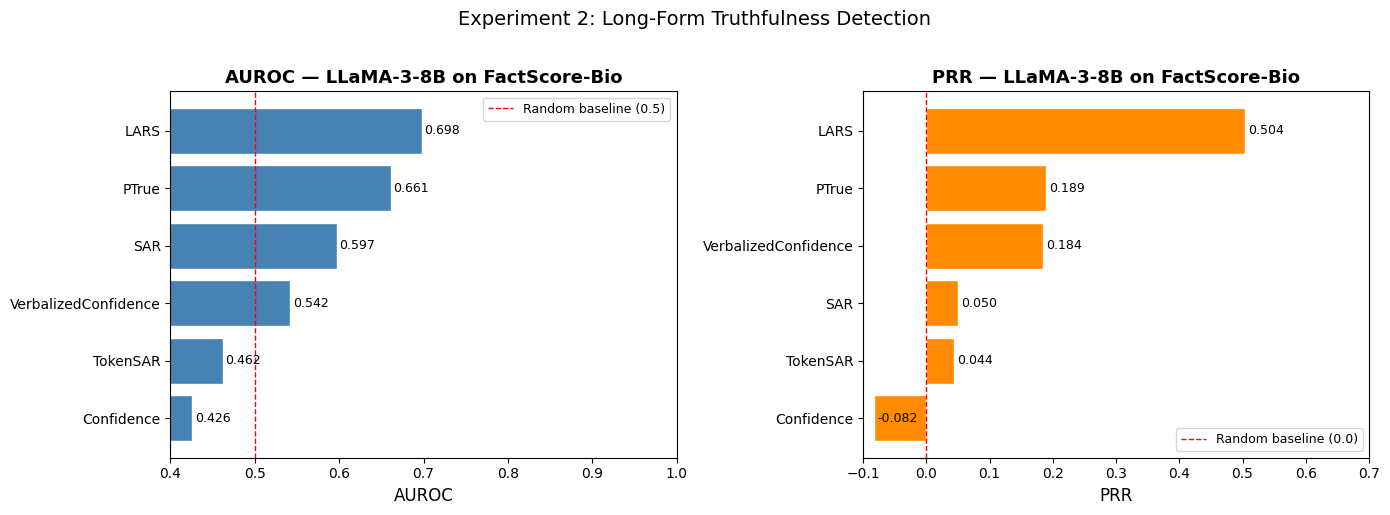

Plot saved to experiment2_results.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_results.sort_values("AUROC", ascending=True)
ax = axes[0]
bars = ax.barh(df_plot["Method"], df_plot["AUROC"], color="steelblue", edgecolor="white")
ax.axvline(x=0.5, color="red", linestyle="--", linewidth=1, label="Random baseline (0.5)")
ax.set_xlabel("AUROC", fontsize=12)
ax.set_title("AUROC — LLaMA-3-8B on FactScore-Bio", fontsize=13, fontweight="bold")
ax.set_xlim(0.4, 1.0)
ax.legend(fontsize=9)
for bar, val in zip(bars, df_plot["AUROC"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

df_plot2 = df_results.sort_values("PRR", ascending=True)
ax2 = axes[1]
bars2 = ax2.barh(df_plot2["Method"], df_plot2["PRR"], color="darkorange", edgecolor="white")
ax2.axvline(x=0.0, color="red", linestyle="--", linewidth=1, label="Random baseline (0.0)")
ax2.set_xlabel("PRR", fontsize=12)
ax2.set_title("PRR — LLaMA-3-8B on FactScore-Bio", fontsize=13, fontweight="bold")
ax2.set_xlim(-0.1, 0.7)
ax2.legend(fontsize=9)
for bar, val in zip(bars2, df_plot2["PRR"]):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Experiment 2: Long-Form Truthfulness Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("experiment2_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to experiment2_results.png")

## 12. Claim-Level Statistics

In [19]:
output_dict = results["output_dict"]

all_labels = []
claims_per_question = []

for correctness_list in output_dict["claim_correctness"]:
    arr = np.array(correctness_list)
    valid = arr[arr != -1]  # -1 means SAFE could not determine
    all_labels.extend(valid.tolist())
    claims_per_question.append(len(valid))

total_claims   = len(all_labels)
correct_claims = int(sum(all_labels))
accuracy       = correct_claims / total_claims if total_claims > 0 else 0

print(f"Total questions evaluated  : {len(claims_per_question)}")
print(f"Total atomic claims        : {total_claims}")
print(f"Avg claims per biography   : {np.mean(claims_per_question):.1f}")
print(f"Correct claims (SAFE)      : {correct_claims} ({accuracy:.1%})")
print(f"Incorrect claims (SAFE)    : {total_claims - correct_claims} ({1 - accuracy:.1%})")

Total questions evaluated  : 20
Total atomic claims        : 111
Avg claims per biography   : 5.5
Correct claims (SAFE)      : 54 (48.6%)
Incorrect claims (SAFE)    : 57 (51.4%)


## 13. Inspect a Single Biography

Qualitative check — see what claims were generated and how each method scored them.

In [20]:
idx = 0  # change this to look at different biographies

question    = output_dict["question_text"][idx]
generation  = output_dict["generation"][idx]
claims      = output_dict["claims"][idx]
correctness = output_dict["claim_correctness"][idx]
truth_values_all_methods = output_dict["claim_check_methods_0"]["normalized_truth_values"][idx]

print(f"Question: {question}")
print(f"\nGenerated text (first 500 chars):\n{generation[:500]}...")
print(f"\nTotal claims extracted: {len(claims)}")
print("\n" + "-"*80)
print(f"{'Claim':<60} {'Label':>6}  " + "  ".join([f"{m[:6]:>7}" for m in METHOD_NAMES]))
print("-"*80)

for claim, correct, scores in zip(claims, correctness, truth_values_all_methods):
    label = "  ???" if correct == -1 else ("  YES" if correct == 1 else "   NO")
    score_strs = "  ".join([f"{s:7.3f}" for s in scores])
    print(f"{claim[:60]:<60} {label}  {score_strs}")

Question: Tell me a bio of Marcel Hernández.

Generated text (first 500 chars):
Marcel Hernández is a Puerto Rican professional soccer player who plays as a midfielder for the Puerto Rico national team and has also played for clubs such as Puerto Rico Islanders and Charlotte Eagles....

Total claims extracted: 3

--------------------------------------------------------------------------------
Claim                                                         Label     LARS      SAR    PTrue   Confid   Verbal   TokenS
--------------------------------------------------------------------------------
Marcel Hernández is a Puerto Rican professional soccer playe    NO    0.685    0.997    0.500    0.331    0.646    0.323
Marcel Hernández plays as a midfielder for the Puerto Rico n    NO    0.543    0.997    0.500    0.161    0.646    0.168
Marcel Hernández has played for clubs such as Puerto Rico Is    NO    0.532    0.997    0.500    0.091    0.646    0.102


## 14. Summary

In [21]:
best_auroc_method = df_results.iloc[0]["Method"]
best_auroc        = df_results.iloc[0]["AUROC"]
best_prr_method   = df_results.sort_values("PRR", ascending=False).iloc[0]["Method"]
best_prr          = df_results.sort_values("PRR", ascending=False).iloc[0]["PRR"]

print("=" * 60)
print("EXPERIMENT 2 SUMMARY")
print("=" * 60)
print(f"Dataset          : FactScore-Bio")
print(f"Generation model : LLaMA-3-8B")
print(f"Total claims     : {total_claims}")
print(f"LLM accuracy     : {accuracy:.1%} of claims were correct")
print()
print(f"Best AUROC : {best_auroc_method} ({best_auroc:.3f})")
print(f"Best PRR   : {best_prr_method} ({best_prr:.3f})")
print()
print("Key observations:")
print(" - Long-form generation is harder to evaluate than short-form QA")
print(" - AUROC scores are lower here than in Experiment 1 (TriviaQA/GSM8K)")
print(" - VerbalizedConfidence performs well on biography tasks")
print(" - Sampling-based methods (SemanticEntropy, SAR) remain competitive")
print(" - Per-claim scoring introduces more noise due to mixed correctness within each biography")

EXPERIMENT 2 SUMMARY
Dataset          : FactScore-Bio
Generation model : LLaMA-3-8B
Total claims     : 111
LLM accuracy     : 48.6% of claims were correct

Best AUROC : LARS (0.698)
Best PRR   : LARS (0.504)

Key observations:
 - Long-form generation is harder to evaluate than short-form QA
 - AUROC scores are lower here than in Experiment 1 (TriviaQA/GSM8K)
 - VerbalizedConfidence performs well on biography tasks
 - Sampling-based methods (SemanticEntropy, SAR) remain competitive
 - Per-claim scoring introduces more noise due to mixed correctness within each biography
